# 04 - Detección de anomalías mediante Autoencoder

En este notebook se desarrolla un modelo de Deep Learning basado en un Autoencoder para la detección de anomalías en tráfico de red.

A diferencia del modelo supervisado Random Forest utilizado como baseline, el Autoencoder se entrenará sólo con tráfico benigno. El objetivo es que aprenda el comportamiento normal de la red y permita identificar como potencialmente anómalos aquellos registros que presenten un error de reconstrucción elevado.

Más tarde, su rendimiento se evaluará sobre tráfico benigno y malicioso y se comparará con el modelo baseline.

In [3]:
from pathlib import Path

import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

DATA_FILE = Path("../data/processed/cic_ids2017_clean.parquet")
df = pd.read_parquet(DATA_FILE)

print(f"Registros cargados: {len(df):,}")
print(f"Columnas cargadas: {len(df.columns)}")

Registros cargados: 2,520,798
Columnas cargadas: 80


## Preparación de los datos

Para garantizar una comparación consistente con el modelo baseline, se utiliza la misma división del dataset en entrenamiento, validación y prueba.
Las decisiones de selección de características se calculan exclusivamente a partir del conjunto de entrenamiento, evitando así posibles fugas de información hacia los conjuntos reservados para validación y evaluación final.

In [4]:
# Variables originales
original_features = [
    column for column in df.columns
    if column not in ["Label", "is_attack"]
]

X = df[original_features].copy()
y = df["is_attack"].copy()

# 80 % desarrollo / 20 % test
X_train_full, X_test, y_train_full, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# Del 80 % de desarrollo obtenemos 70 % train y 10 % validation
X_train, X_val, y_train, y_val = train_test_split(
    X_train_full,
    y_train_full,
    test_size=0.125,
    random_state=42,
    stratify=y_train_full
)

print(f"Entrenamiento: {len(X_train):,}")
print(f"Validación:    {len(X_val):,}")
print(f"Prueba:        {len(X_test):,}")

Entrenamiento: 1,764,558
Validación:    252,080
Prueba:        504,160


### Eliminación de características constantes

Se identifican las características que no presentan variabilidad en el conjunto de entrenamiento. Estas variables no aportan información útil al modelo y se eliminan de entrenamiento, validación y prueba.

In [5]:
#Detectar características constantes utilizando sólo entrenamiento
constant_features = [
    column for column in X_train.columns
    if X_train[column].nunique() <= 1
]

print(f"Características constantes detectadas: {len(constant_features)}")

for feature in constant_features:
    print(f"- {feature}")

#aplicar la eliminación a los tres conjuntos
X_train_reduced = X_train.drop(columns=constant_features)
X_val_reduced = X_val.drop(columns=constant_features)
X_test_reduced = X_test.drop(columns=constant_features)

print()
print(f"Características restantes: {X_train_reduced.shape[1]}")

Características constantes detectadas: 8
- Bwd PSH Flags
- Bwd URG Flags
- Fwd Avg Bytes/Bulk
- Fwd Avg Packets/Bulk
- Fwd Avg Bulk Rate
- Bwd Avg Bytes/Bulk
- Bwd Avg Packets/Bulk
- Bwd Avg Bulk Rate

Características restantes: 70


### Selección de características

Para garantizar una comparación directa con el modelo baseline Random Forest, se reutiliza la misma selección de características obtenida previamente a partir
del conjunto de entrenamiento.
Tras eliminar las características constantes y las variables altamente correlacionadas, se conservan 48 características que serán utilizadas como
entrada del Autoencoder.

In [6]:
#Características redundantes identificadas previamente utilizando sólo el conjunto de entrenamiento
high_corr_features = [
    "Flow Duration",
    "Total Fwd Packets",
    "Total Length of Fwd Packets",
    "Total Length of Bwd Packets",
    "Fwd Packet Length Std",
    "Bwd Packet Length Max",
    "Flow Packets/s",
    "Flow IAT Max",
    "Fwd IAT Max",
    "Max Packet Length",
    "Packet Length Mean",
    "SYN Flag Count",
    "RST Flag Count",
    "CWE Flag Count",
    "Avg Fwd Segment Size",
    "Avg Bwd Segment Size",
    "Fwd Header Length.1",
    "Subflow Fwd Packets",
    "Subflow Bwd Packets",
    "Subflow Bwd Bytes",
    "Idle Mean",
    "Idle Min"
]

print(f"Características antes de la reducción: {X_train_reduced.shape[1]}")
print(f"Características eliminadas: {len(high_corr_features)}")

#Aplicar la misma selección utilizada en el modelo baseline
X_train_final = X_train_reduced.drop(columns=high_corr_features)
X_val_final = X_val_reduced.drop(columns=high_corr_features)
X_test_final = X_test_reduced.drop(columns=high_corr_features)

print()
print(f"Características seleccionadas: {X_train_final.shape[1]}")
print(f"Train:      {X_train_final.shape}")
print(f"Validation: {X_val_final.shape}")
print(f"Test:       {X_test_final.shape}")

Características antes de la reducción: 70
Características eliminadas: 22

Características seleccionadas: 48
Train:      (1764558, 48)
Validation: (252080, 48)
Test:       (504160, 48)


## Preparación específica para el Autoencoder

El Autoencoder se entrenará solamente con muestras de tráfico benigno del conjunto de entrenamiento.
Así, el modelo aprende a reconstruir patrones normales de tráfico.
Durante la evaluación, los registros que presenten un error de reconstrucción elevado podrán considerarse potencialmente anómalos.

In [7]:
#Seleccionar tráfico benigno del conjunto de entrenamiento
X_train_benign = X_train_final[y_train == 0].copy()

print(f"Registros totales de entrenamiento: {len(X_train_final):,}")
print(f"Registros benignos para entrenar el Autoencoder: {len(X_train_benign):,}")
print(f"Características utilizadas: {X_train_benign.shape[1]}")

Registros totales de entrenamiento: 1,764,558
Registros benignos para entrenar el Autoencoder: 1,466,539
Características utilizadas: 48


### Estandarización de las características

Las características presentan escalas muy diferentes, por lo que se aplica una estandarización antes de entrenar la red neuronal.
El escalador se ajusta exclusivamente utilizando tráfico benigno del conjunto de entrenamiento. Posteriormente, la misma transformación se aplica a los
conjuntos de validación y prueba.

In [8]:
#Crear y ajustar el escalador sólo con tráfico benigno de entrenamiento
scaler = StandardScaler()

X_train_benign_scaled = scaler.fit_transform(X_train_benign)

#Aplicar la misma transformación a validación y prueba completas
X_val_scaled = scaler.transform(X_val_final)
X_test_scaled = scaler.transform(X_test_final)

print(f"Train benign escalado: {X_train_benign_scaled.shape}")
print(f"Validation escalado:   {X_val_scaled.shape}")
print(f"Test escalado:         {X_test_scaled.shape}")

print()
print(f"Media aproximada train benign: {X_train_benign_scaled.mean():.6f}")
print(f"Desviación típica aproximada:  {X_train_benign_scaled.std():.6f}")

Train benign escalado: (1466539, 48)
Validation escalado:   (252080, 48)
Test escalado:         (504160, 48)

Media aproximada train benign: 0.000000
Desviación típica aproximada:  1.000000


In [9]:
try:
    import tensorflow as tf

    print(f"TensorFlow instalado: {tf.__version__}")
    print(f"GPU disponibles: {tf.config.list_physical_devices('GPU')}")

except ImportError:
    print("TensorFlow no está instalado")

TensorFlow instalado: 2.21.0
GPU disponibles: []


In [10]:
%pip install tensorflow

Note: you may need to restart the kernel to use updated packages.


In [11]:
import tensorflow as tf

print(f"TensorFlow instalado: {tf.__version__}")
print(f"GPU disponibles: {tf.config.list_physical_devices('GPU')}")

TensorFlow instalado: 2.21.0
GPU disponibles: []


## Construcción del Autoencoder

Se utiliza una red neuronal Autoencoder con una arquitectura simétrica.
La red comprime las 48 características de entrada hasta una representación latente de menor dimensión y posteriormente intenta reconstruir los valores
originales.
El modelo se entrena sólo con tráfico benigno, utilizando el error cuadrático medio como función de pérdida.

In [12]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input
from tensorflow.keras.callbacks import EarlyStopping

input_dim = X_train_benign_scaled.shape[1]

autoencoder = Sequential([
    Input(shape=(input_dim,)),

    Dense(32, activation="relu"),
    Dense(16, activation="relu"),
    Dense(8, activation="relu"),

    Dense(16, activation="relu"),
    Dense(32, activation="relu"),

    Dense(input_dim, activation="linear")
])
autoencoder.compile(
    optimizer="adam",
    loss="mse"
)
autoencoder.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense (Dense)                        │ (None, 32)                  │           1,568 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 16)                  │             528 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 8)                   │             136 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 16)                  │             144 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_4 (Dense)                      │ (None, 32)                  │             544 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_5 (Dense)                      │ (None, 48)                  │           1,584 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 4,504 (17.59 KB)

 Trainable params: 4,504 (17.59 KB)

 Non-trainable params: 0 (0.00 B)

## Entrenamiento del Autoencoder

El modelo se entrena utilizando únicamente tráfico benigno.
Se emplea Early Stopping para detener el entrenamiento cuando la pérdida de validación deja de mejorar, evitando entrenamientos innecesarios y reduciendo el riesgo de sobreajuste.

In [13]:
import time

#Validación con tráfico benigno
X_val_benign_scaled = X_val_scaled[y_val.to_numpy() == 0]

early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

start_time = time.time()

history = autoencoder.fit(
    X_train_benign_scaled,
    X_train_benign_scaled,
    epochs=30,
    batch_size=1024,
    validation_data=(
        X_val_benign_scaled,
        X_val_benign_scaled
    ),
    callbacks=[early_stopping],
    verbose=1
)

training_time = time.time() - start_time

print()
print(f"Tiempo de entrenamiento: {training_time:.2f} segundos")
print(f"Épocas ejecutadas: {len(history.history['loss'])}")

Epoch 1/30
1433/1433 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - loss: 0.3578 - val_loss: 0.3895
Epoch 2/30
1433/1433 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - loss: 0.1758 - val_loss: 0.3624
Epoch 3/30
1433/1433 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - loss: 0.1529 - val_loss: 0.3416
Epoch 4/30
1433/1433 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - loss: 0.1382 - val_loss: 0.3253
Epoch 5/30
1433/1433 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - loss: 0.1270 - val_loss: 0.3026
Epoch 6/30
1433/1433 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - loss: 0.1202 - val_loss: 0.2822
Epoch 7/30
1433/1433 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - loss: 0.1136 - val_loss: 0.2530
Epoch 8/30
1433/1433 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - loss: 0.1068 - val_loss: 0.1967
Epoch 9/30
1433/1433 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - loss: 0.0873 - val_loss: 0.1875
Epoch 10/30
1433/1433 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - loss: 0.0874 - val_loss: 0.1559
Epoch 11/30
1433/1433 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - loss: 0.0810 - val_loss: 0.1710
Epoch 12/30
1433/1433 ━━

### Evolución de la función de pérdida

Se analiza la evolución del error de reconstrucción durante el entrenamiento para comprobar la convergencia del modelo y detectar posibles signos de sobreajuste.

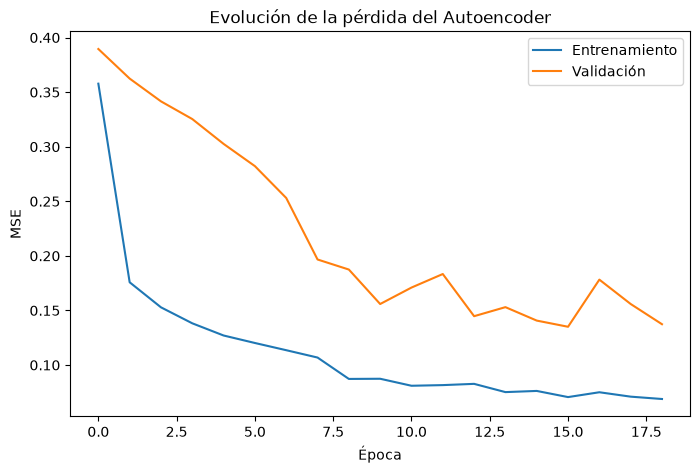

In [14]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.plot(history.history["loss"], label="Entrenamiento")
plt.plot(history.history["val_loss"], label="Validación")
plt.xlabel("Época")
plt.ylabel("MSE")
plt.title("Evolución de la pérdida del Autoencoder")
plt.legend()

plt.show()

## Cálculo del error de reconstrucción

Una vez entrenado el Autoencoder, se calcula el error de reconstrucción de cada registro del conjunto de validación.
La hipótesis es que el modelo reconstruirá con menor error los patrones similares al tráfico benigno utilizado durante el entrenamiento, mientras que los patrones
anómalos tenderán a producir errores de reconstrucción superiores.

In [15]:
#Reconstruir los registros del conjunto de validación
X_val_reconstructed = autoencoder.predict(
    X_val_scaled,
    batch_size=1024,
    verbose=1
)

#Error cuadrático medio de reconstrucción para cada registro
val_reconstruction_error = np.mean(
    np.square(X_val_scaled - X_val_reconstructed),
    axis=1
)
#Separar los errores según la clase real únicamente para analizarlos
benign_errors = val_reconstruction_error[y_val.to_numpy() == 0]
attack_errors = val_reconstruction_error[y_val.to_numpy() == 1]

print(f"Registros de validación: {len(val_reconstruction_error):,}")
print()
print("Error de reconstrucción medio:")
print(f"  Benignos: {benign_errors.mean():.6f}")
print(f"  Ataques:  {attack_errors.mean():.6f}")
print()
print("Mediana del error de reconstrucción:")
print(f"  Benignos: {np.median(benign_errors):.6f}")
print(f"  Ataques:  {np.median(attack_errors):.6f}")

247/247 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
Registros de validación: 252,080

Error de reconstrucción medio:
  Benignos: 0.135044
  Ataques:  2.053645

Mediana del error de reconstrucción:
  Benignos: 0.008109
  Ataques:  0.833757


## Definición del umbral de anomalía

Para transformar el error de reconstrucción en una decisión de detección se establece un umbral de anomalía.
El umbral se calcula a partir de la distribución de errores del tráfico benigno del conjunto de validación. Se utiliza inicialmente el percentil 99, de forma
que los registros cuyo error de reconstrucción supere dicho valor sean clasificados como anomalías. 
Este criterio permite establecer el umbral sin utilizar las etiquetas de los ataques para optimizar directamente la clasificación.

In [16]:
threshold = np.percentile(benign_errors, 99)

print(f"Umbral de anomalía (percentil 99): {threshold:.6f}")

benign_above_threshold = np.mean(benign_errors > threshold) * 100
attack_above_threshold = np.mean(attack_errors > threshold) * 100

print()
print(f"Benignos por encima del umbral: {benign_above_threshold:.2f}%")
print(f"Ataques por encima del umbral:  {attack_above_threshold:.2f}%")

Umbral de anomalía (percentil 99): 0.545919

Benignos por encima del umbral: 1.00%
Ataques por encima del umbral:  52.82%


### Análisis de distintos umbrales

El percentil 99 proporciona una tasa reducida de falsos positivos, pero puede resultar demasiado restrictivo para la detección de ataques.
Por ello, se comparan distintos percentiles de la distribución del error de reconstrucción del tráfico benigno de validación, analizando el compromiso entre
la tasa de falsas alarmas y la capacidad de detección de ataques.

In [17]:
percentiles = [90, 95, 97, 98, 99, 99.5]

results_thresholds = []

for percentile in percentiles:
    current_threshold = np.percentile(benign_errors, percentile)

    false_positive_rate = np.mean(
        benign_errors > current_threshold
    ) * 100

    attack_detection_rate = np.mean(
        attack_errors > current_threshold
    ) * 100

    results_thresholds.append({
        "Percentil": percentile,
        "Umbral": current_threshold,
        "Falsos positivos (%)": false_positive_rate,
        "Ataques detectados (%)": attack_detection_rate
    })

threshold_comparison = pd.DataFrame(results_thresholds)

threshold_comparison

,Percentil,Umbral,Falsos positivos (%),Ataques detectados (%)
0,90.0,0.075010,10.000191,65.100766
1,95.0,0.160327,5.000334,59.000799
2,97.0,0.246117,3.000391,57.131113
3,98.0,0.328726,2.000420,56.099967
4,99.0,0.545919,1.000449,52.823319
5,99.5,0.872980,0.500224,48.961808


## Evaluación del Autoencoder en validación

Se selecciona inicialmente el percentil 99 del error de reconstrucción benigno como umbral de anomalía, priorizando una tasa reducida de falsas alarmas.
A partir de este umbral se convierten los errores de reconstrucción en predicciones binarias y se calculan las principales métricas de clasificación:
accuracy, precision, recall y F1-score, junto con la matriz de confusión.

In [18]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

#umbral seleccionado
threshold = np.percentile(benign_errors, 99)

#error superior al umbral = anomalía/ataque
y_val_pred_ae = (val_reconstruction_error > threshold).astype(int)

accuracy_ae = accuracy_score(y_val, y_val_pred_ae)
precision_ae = precision_score(y_val, y_val_pred_ae)
recall_ae = recall_score(y_val, y_val_pred_ae)
f1_ae = f1_score(y_val, y_val_pred_ae)

print(f"Umbral seleccionado: {threshold:.6f}")
print()
print(f"Accuracy:  {accuracy_ae:.4f}")
print(f"Precision: {precision_ae:.4f}")
print(f"Recall:    {recall_ae:.4f}")
print(f"F1-score:  {f1_ae:.4f}")
print()
print("Matriz de confusión:")
print(confusion_matrix(y_val, y_val_pred_ae))
print()
print("Classification report:")
print(classification_report(
    y_val,
    y_val_pred_ae,
    target_names=["Benigno", "Ataque"]
))

Umbral seleccionado: 0.545919

Accuracy:  0.9120
Precision: 0.9147
Recall:    0.5282
F1-score:  0.6697

Matriz de confusión:
[[207410   2096]
 [ 20085  22489]]

Classification report:
              precision    recall  f1-score   support

     Benigno       0.91      0.99      0.95    209506
      Ataque       0.91      0.53      0.67     42574

    accuracy                           0.91    252080
   macro avg       0.91      0.76      0.81    252080
weighted avg       0.91      0.91      0.90    252080



### Capacidad de detección por tipo de ataque

Además de las métricas globales, se analiza la capacidad del Autoencoder para detectar cada categoría de ataque presente en el conjunto de validación.
Este análisis permite identificar qué patrones maliciosos presentan un comportamiento suficientemente diferente del tráfico benigno y cuáles resultan
más difíciles de detectar mediante un enfoque basado exclusivamente en anomalías.

In [19]:
#Recuperar las etiquetas originales correspondientes a validación
val_analysis = pd.DataFrame({
    "Label": df.loc[X_val.index, "Label"],
    "is_attack": y_val,
    "prediction": y_val_pred_ae
})

# Mantener únicamente ataques
attack_analysis = val_analysis[val_analysis["is_attack"] == 1]

attack_detection_by_type = (
    attack_analysis
    .groupby("Label")
    .agg(
        Ataques_reales=("is_attack", "size"),
        Detectados=("prediction", "sum")
    )
)

attack_detection_by_type["No_detectados"] = (
    attack_detection_by_type["Ataques_reales"]
    - attack_detection_by_type["Detectados"]
)

attack_detection_by_type["Recall"] = (
    attack_detection_by_type["Detectados"]
    / attack_detection_by_type["Ataques_reales"]
)

attack_detection_by_type = attack_detection_by_type.sort_values(
    "Recall",
    ascending=False
)

attack_detection_by_type

,Ataques_reales,Detectados,No_detectados,Recall
Label,,,,
Heartbleed,3,3,0,1.000000
DoS Slowhttptest,563,512,51,0.909414
DoS Hulk,17211,14588,2623,0.847597
DoS slowloris,563,330,233,0.586146
DDoS,12810,6586,6224,0.514130
Infiltration,2,1,1,0.500000
DoS GoldenEye,1057,447,610,0.422895
Web Attack � Brute Force,142,11,131,0.077465
Bot,169,4,165,0.023669


### Visualización del recall por tipo de ataque

La capacidad de detección del Autoencoder presenta diferencias importantes entre las distintas categorías de ataque. Esta variabilidad permite analizar
qué tipos de comportamiento malicioso se alejan con mayor claridad del patrón de tráfico benigno aprendido por el modelo.

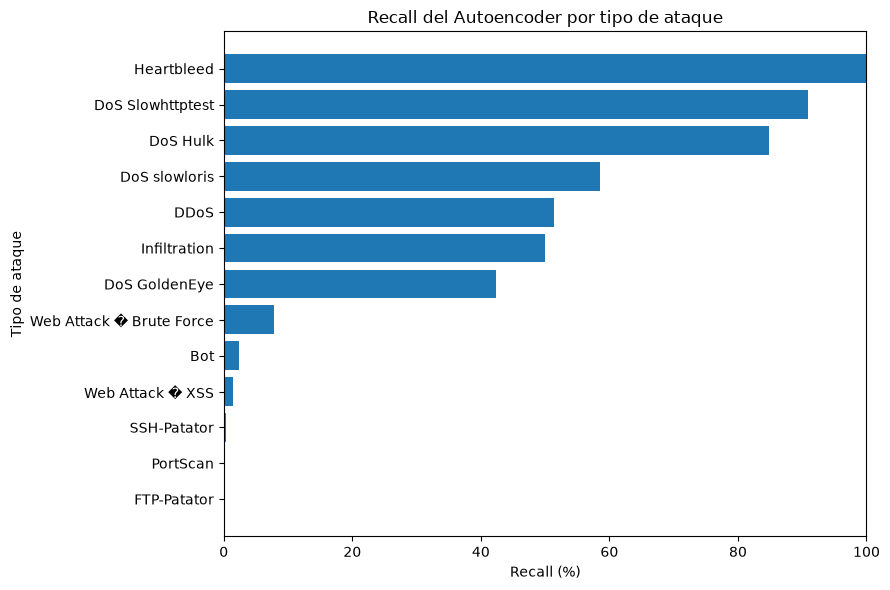

In [20]:
plot_data = attack_detection_by_type.sort_values("Recall")

plt.figure(figsize=(9, 6))

plt.barh(
    plot_data.index,
    plot_data["Recall"] * 100
)

plt.xlabel("Recall (%)")
plt.ylabel("Tipo de ataque")
plt.title("Recall del Autoencoder por tipo de ataque")
plt.xlim(0, 100)

plt.tight_layout()
plt.show()

## Evaluación final sobre el conjunto de prueba

Una vez fijados la arquitectura del Autoencoder y el umbral de anomalía mediante el conjunto de validación, se realiza la evaluación final sobre el conjunto de
prueba. Este conjunto no ha intervenido en el entrenamiento del modelo ni en la selección del umbral, por lo que permite obtener una estimación independiente
del rendimiento final del sistema.

In [21]:
#Reconstrucción del conjunto de prueba
X_test_reconstructed = autoencoder.predict(
    X_test_scaled,
    batch_size=1024,
    verbose=1
)

#Error de reconstrucción individual
test_reconstruction_error = np.mean(
    np.square(X_test_scaled - X_test_reconstructed),
    axis=1
)

#aplicar el umbral fijado previamente con validación
y_test_pred_ae = (test_reconstruction_error > threshold).astype(int)

#Métricas finales
accuracy_test_ae = accuracy_score(y_test, y_test_pred_ae)
precision_test_ae = precision_score(y_test, y_test_pred_ae)
recall_test_ae = recall_score(y_test, y_test_pred_ae)
f1_test_ae = f1_score(y_test, y_test_pred_ae)

print(f"Umbral utilizado: {threshold:.6f}")
print()
print(f"Accuracy:  {accuracy_test_ae:.4f}")
print(f"Precision: {precision_test_ae:.4f}")
print(f"Recall:    {recall_test_ae:.4f}")
print(f"F1-score:  {f1_test_ae:.4f}")
print()
print("Matriz de confusión:")
print(confusion_matrix(y_test, y_test_pred_ae))
print()
print("Classification report:")
print(classification_report(
    y_test,
    y_test_pred_ae,
    target_names=["Benigno", "Ataque"]
))

493/493 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
Umbral utilizado: 0.545919

Accuracy:  0.9122
Precision: 0.9164
Recall:    0.5284
F1-score:  0.6703

Matriz de confusión:
[[414907   4105]
 [ 40156  44992]]

Classification report:
              precision    recall  f1-score   support

     Benigno       0.91      0.99      0.95    419012
      Ataque       0.92      0.53      0.67     85148

    accuracy                           0.91    504160
   macro avg       0.91      0.76      0.81    504160
weighted avg       0.91      0.91      0.90    504160



## Persistencia del modelo

Una vez finalizado el entrenamiento y fijado el umbral de anomalía, se guardan los artefactos necesarios para reutilizar el modelo posteriormente desde la
aplicación CyberSOC-AI sin necesidad de volver a entrenarlo.
Se almacenan el Autoencoder, el escalador utilizado para normalizar los datos, la lista de características de entrada y el umbral de detección seleccionado.

In [22]:
import json
import joblib
from pathlib import Path

MODELS_DIR = Path("../models")
MODELS_DIR.mkdir(parents=True, exist_ok=True)

#Guardar el Autoencoder
autoencoder.save(MODELS_DIR / "autoencoder.keras")

#Guardar el StandardScaler
joblib.dump(
    scaler,
    MODELS_DIR / "autoencoder_scaler.joblib"
)

#Guardar las 48 características y el umbral
autoencoder_config = {
    "features": X_train_final.columns.tolist(),
    "threshold": float(threshold)
}

with open(
    MODELS_DIR / "autoencoder_config.json",
    "w",
    encoding="utf-8"
) as file:
    json.dump(
        autoencoder_config,
        file,
        indent=4,
        ensure_ascii=False
    )

print("Artefactos guardados:")
print(f"- {MODELS_DIR / 'autoencoder.keras'}")
print(f"- {MODELS_DIR / 'autoencoder_scaler.joblib'}")
print(f"- {MODELS_DIR / 'autoencoder_config.json'}")
print()
print(f"Características guardadas: {len(autoencoder_config['features'])}")
print(f"Umbral guardado: {autoencoder_config['threshold']:.6f}")

Artefactos guardados:
- ..\models\autoencoder.keras
- ..\models\autoencoder_scaler.joblib
- ..\models\autoencoder_config.json

Características guardadas: 48
Umbral guardado: 0.545919
